# EDA -- Hypothesis vs Reality

In [7]:
import sys
from pathlib import Path
import os

# Dynamically resolve the project root and add it to the system path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Standardized directories for notebook usage
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
VISUALS = PROJECT_ROOT / 'visualization'

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style = "whitegrid")

df = pd.read_excel(os.path.join(DATA_DIR, 'Master.xlsx')) 
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].dt.year != 2018]
df['Target_Rate'] = df['Occupied_Rooms'] / df['Total_Rooms']

**This first chart uses a 30-day moving average to smooth out daily "noise". It allows management to see at a glance the catastrophic impact of Covid-19 and the war on occupancy rates, as well as the resilience and summer seasonality of each hotel.**

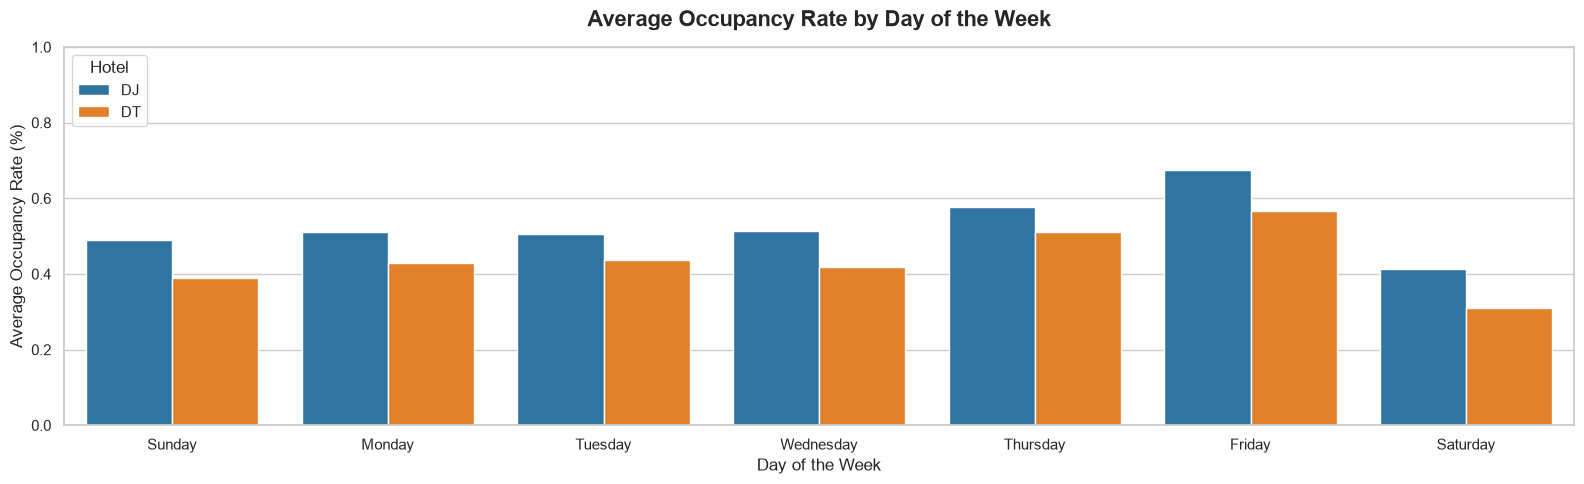

In [9]:
df['DayName'] = df['Date'].dt.day_name()
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='DayName', y='Target_Rate', hue='Hotel_ID', order=day_order, palette=['#1f77b4', '#ff7f0e'], errorbar=None)

plt.title('Average Occupancy Rate by Day of the Week', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Average Occupancy Rate (%)', fontsize=12)
plt.xlabel('Day of the Week', fontsize=12)
plt.legend(title ='Hotel', loc='upper left')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'plot_intra_week.png'), dpi=300)
plt.show()

**This second graph is crucial for the Human Resources Director. It shows the dynamics within a single week. It clearly shows that:**

* Dan Tel Aviv (DT) has a much more "business-oriented" profile mid-week, with a dip over the weekend.
* Dan Jerusalem (DJ) has a very pronounced weekend dynamic (peak on Thursday/Friday), typical of a leisure or religious clientele.

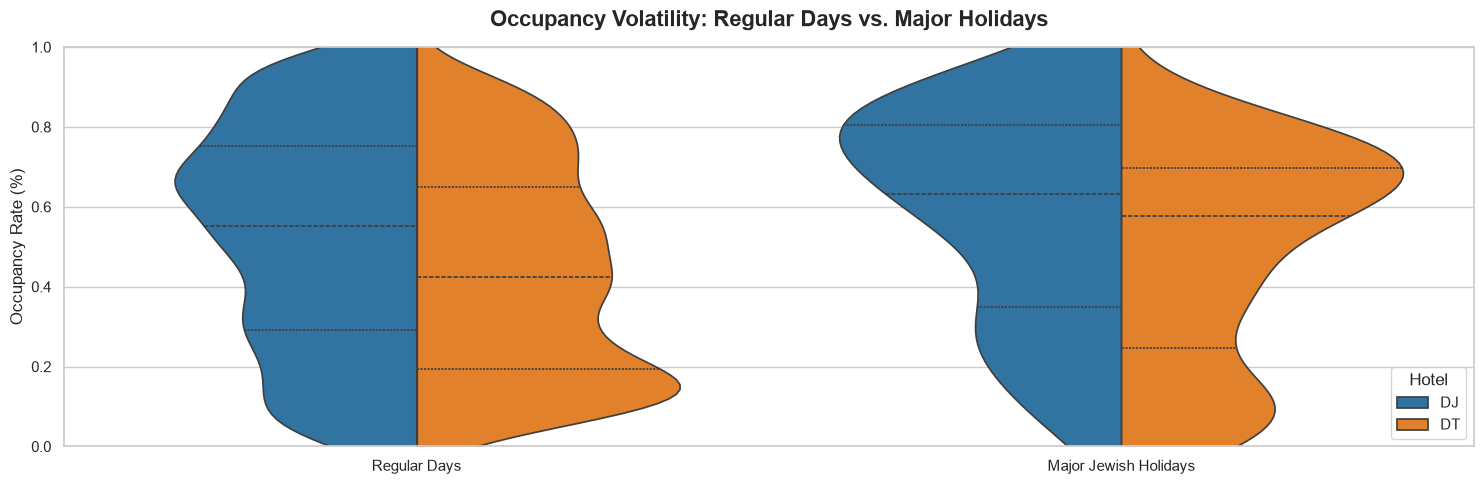

In [10]:
def categorize_day(holiday):
    val = str(holiday).strip().lower()
    if pd.isna(holiday) or val == '0' or val == 'nan' or val == 'none':
        return 'Regular Days'
    elif val in ['passover', 'sukkot', 'rosh hashanah']:
        return 'Major Jewish Holidays'
    else:
        return 'Other Holidays'

df['Day_Category'] = df['Is_Holiday'].apply(categorize_day)

# --- PLOT 1: Occupancy Volatility (Violin Plot) ---
plt.figure(figsize=(15, 5))

# On s'assure de ne garder que les deux catégories cibles
plot_data = df[df['Day_Category'].isin(['Regular Days', 'Major Jewish Holidays'])]

sns.violinplot(data=plot_data, 
            x='Day_Category', y='Target_Rate', hue='Hotel_ID', 
            palette=['#1f77b4', '#ff7f0e'], split=True, inner="quartile")

plt.title('Occupancy Volatility: Regular Days vs. Major Holidays', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Occupancy Rate (%)', fontsize=12)
plt.xlabel('')
plt.legend(title='Hotel', loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'plot_holidays_fixed.png'), dpi=300)
plt.show()

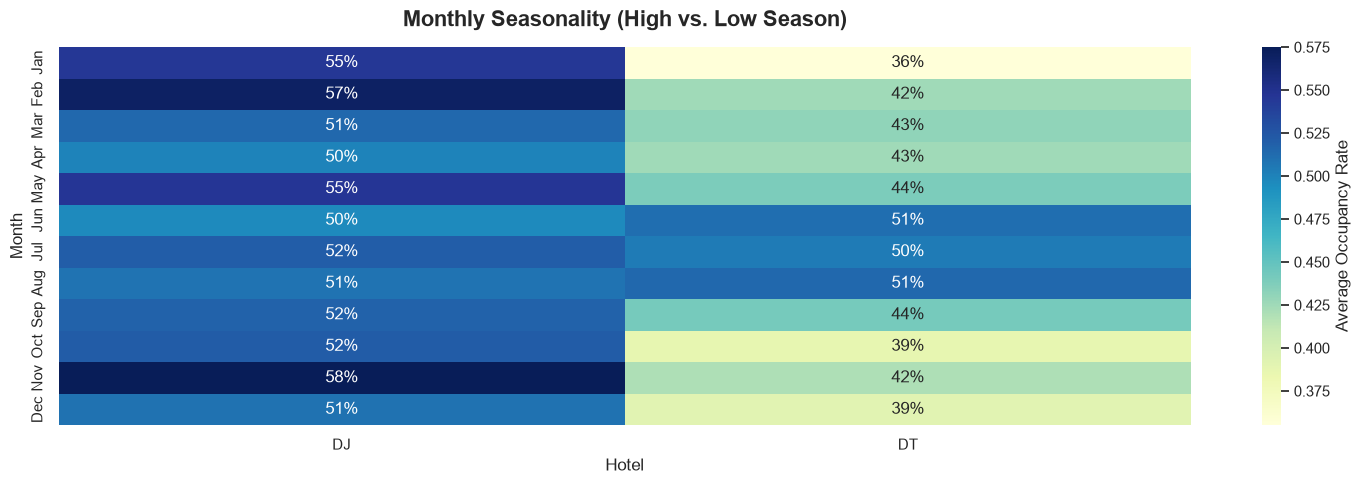

In [11]:
import calendar

heatmap_data = df.groupby(['Month', 'Hotel_ID'])['Target_Rate'].mean().unstack()
# Remplacement des numéros de mois par leurs abréviations (Jan, Feb...)
heatmap_data.index = [calendar.month_abbr[i] for i in heatmap_data.index]

plt.figure(figsize=(15, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0%", cmap="YlGnBu", cbar_kws={'label': 'Average Occupancy Rate'})
plt.title('Monthly Seasonality (High vs. Low Season)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Month', fontsize=12)
plt.xlabel('Hotel', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS,'plot_heatmap.png'), dpi=300)
plt.show()

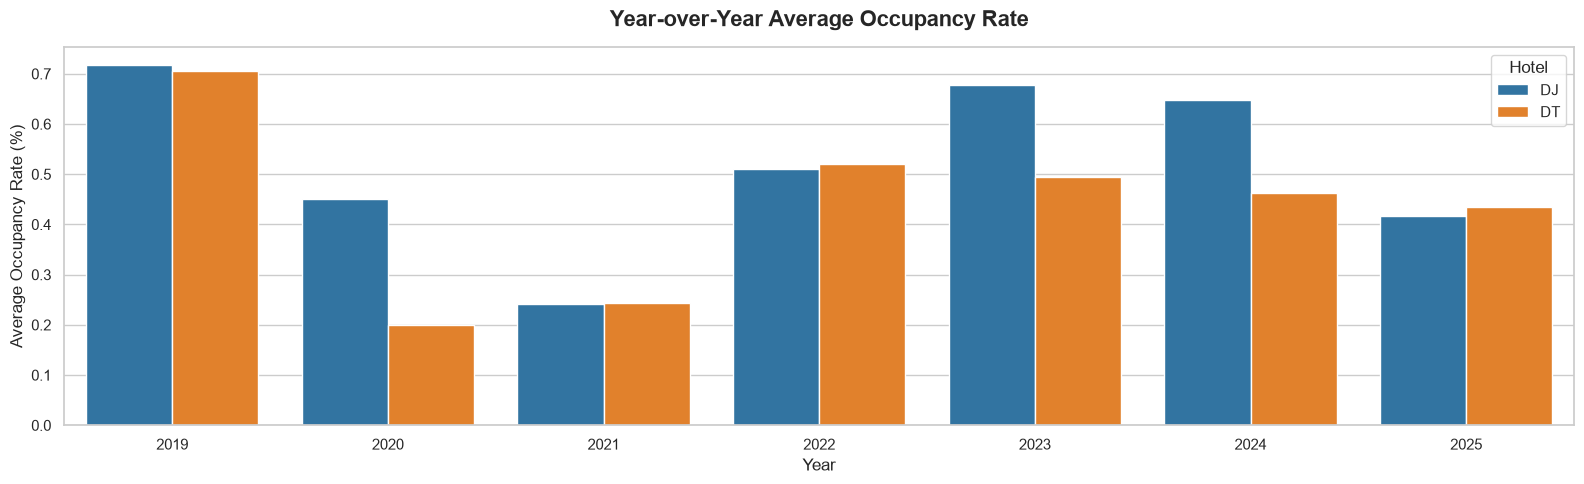

In [12]:
plt.figure(figsize=(16, 5))
yearly_occ = df.groupby(['Year', 'Hotel_ID'])['Target_Rate'].mean().reset_index()

sns.barplot(data=yearly_occ, x='Year', y='Target_Rate', hue='Hotel_ID', palette=['#1f77b4', '#ff7f0e'])

plt.title('Year-over-Year Average Occupancy Rate', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Average Occupancy Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Hotel')
plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'plot_yoy.png'), dpi=300)
plt.show()

### Corona Impact

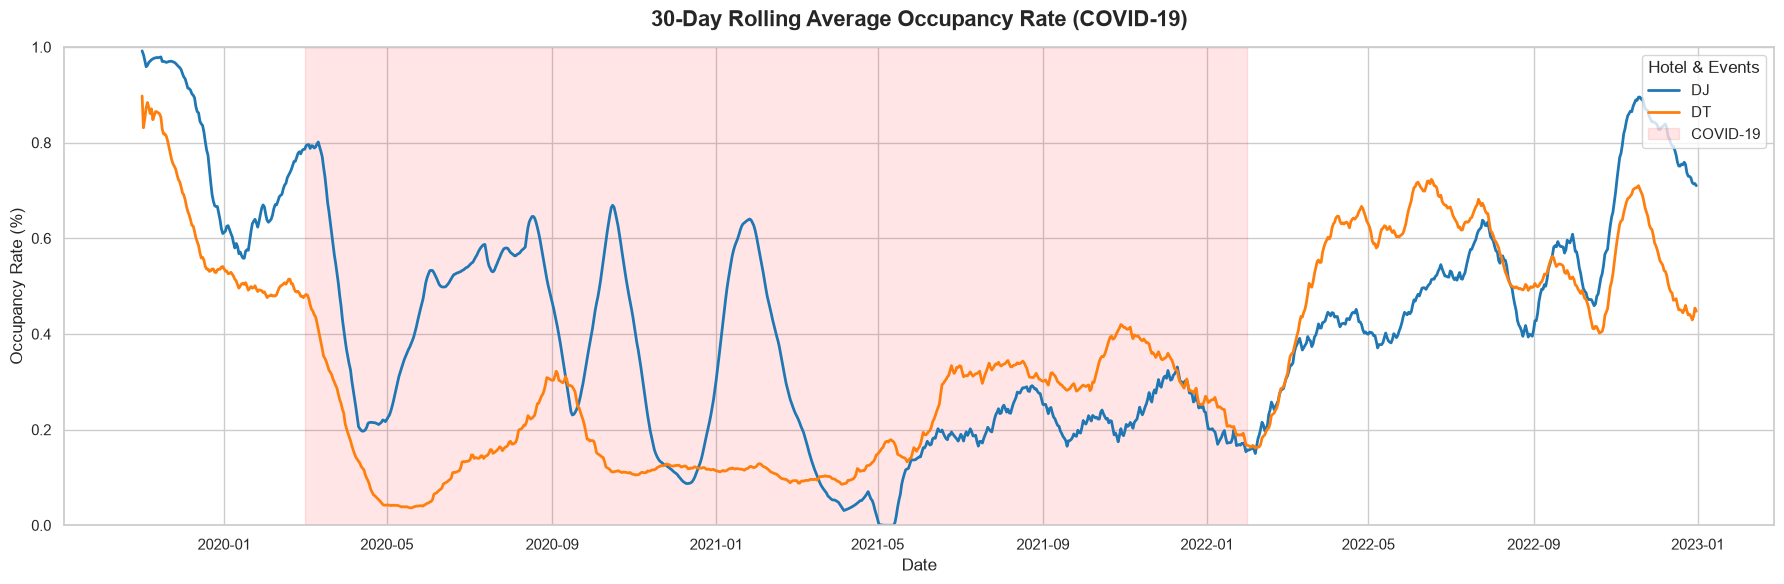

In [13]:
mask = df['Date'].between('2019-11-01', '2022-12-31')
df_covid = df[mask].copy()

plt.figure(figsize=(18, 6))
df_rolling = df_covid.set_index('Date').groupby('Hotel_ID')['Target_Rate'].rolling('30D').mean().reset_index()

sns.lineplot(data=df_rolling, x='Date', y='Target_Rate', hue='Hotel_ID', palette=['#1f77b4', '#ff7f0e'], linewidth=2)
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2022-01-31'), color='red', alpha=0.1, label='COVID-19')

plt.title('30-Day Rolling Average Occupancy Rate (COVID-19)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Occupancy Rate (%)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(title='Hotel & Events', loc='upper right')
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'plot_macro_trend_covid.png'), dpi=300)
plt.show()

### 7-October 2023 Impact

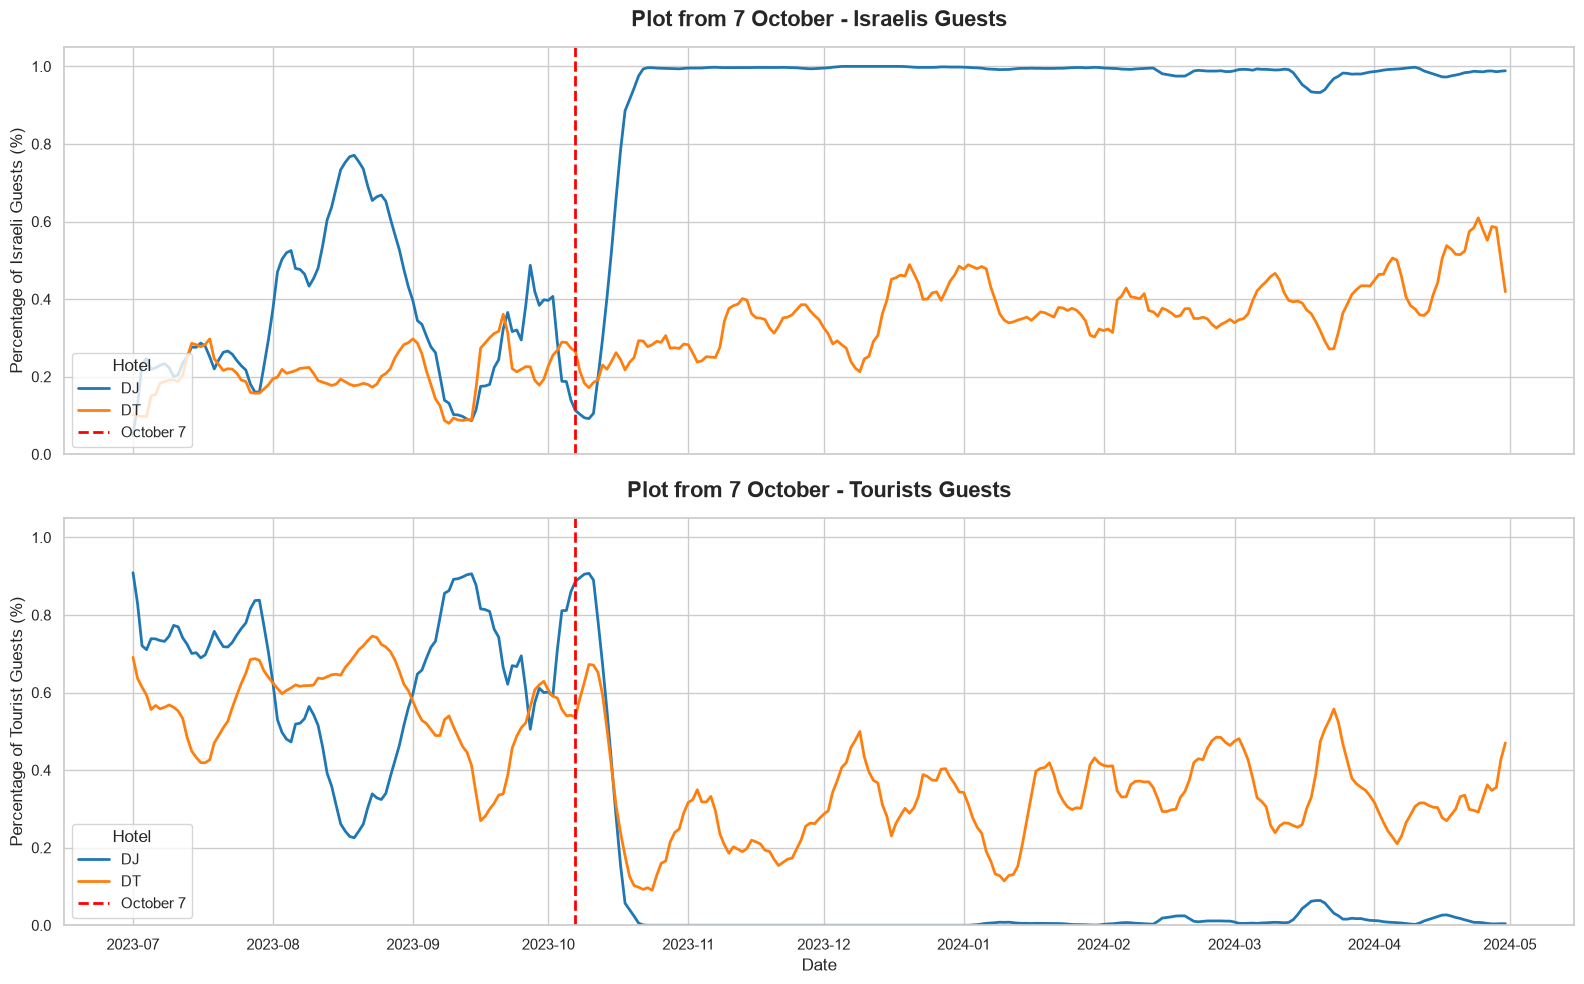

In [14]:
mask = df['Date'].between('2023-07-01', '2024-04-30')
df_plot = df[mask].copy()

df_plot['Rolling_Israelis'] = df_plot.groupby('Hotel_ID')['Percentage_of_Israelis'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df_plot['Rolling_Tourists'] = df_plot.groupby('Hotel_ID')['Percentage_of_Tourists'].transform(lambda x: x.rolling(7, min_periods=1).mean())

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 10), sharex=True)

sns.lineplot(data=df_plot, x='Date', y='Rolling_Israelis', hue='Hotel_ID', palette=['#1f77b4', '#ff7f0e'], linewidth=2, ax=axes[0])
axes[0].axvline(pd.to_datetime('2023-10-07'), color='red', linestyle='--', label='October 7', linewidth=2)
axes[0].set_title('Plot from 7 October - Israelis Guests', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('Percentage of Israeli Guests (%)', fontsize=12)
axes[0].set_xlabel('')
axes[0].legend(title='Hotel', loc='lower left')
axes[0].set_ylim(0, 1.05)

sns.lineplot(data=df_plot, x='Date', y='Rolling_Tourists', hue='Hotel_ID', palette=['#1f77b4', '#ff7f0e'], linewidth=2, ax=axes[1])
axes[1].axvline(pd.to_datetime('2023-10-07'), color='red', linestyle='--', label='October 7', linewidth=2)
axes[1].set_title('Plot from 7 October - Tourists Guests', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('Percentage of Tourist Guests (%)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(title='Hotel', loc='lower left')
axes[1].set_ylim(0, 1.05)

plt.savefig(os.path.join(VISUALS, 'October7_impact.png'), dpi=300)

plt.tight_layout()
plt.show()

#### Predictions

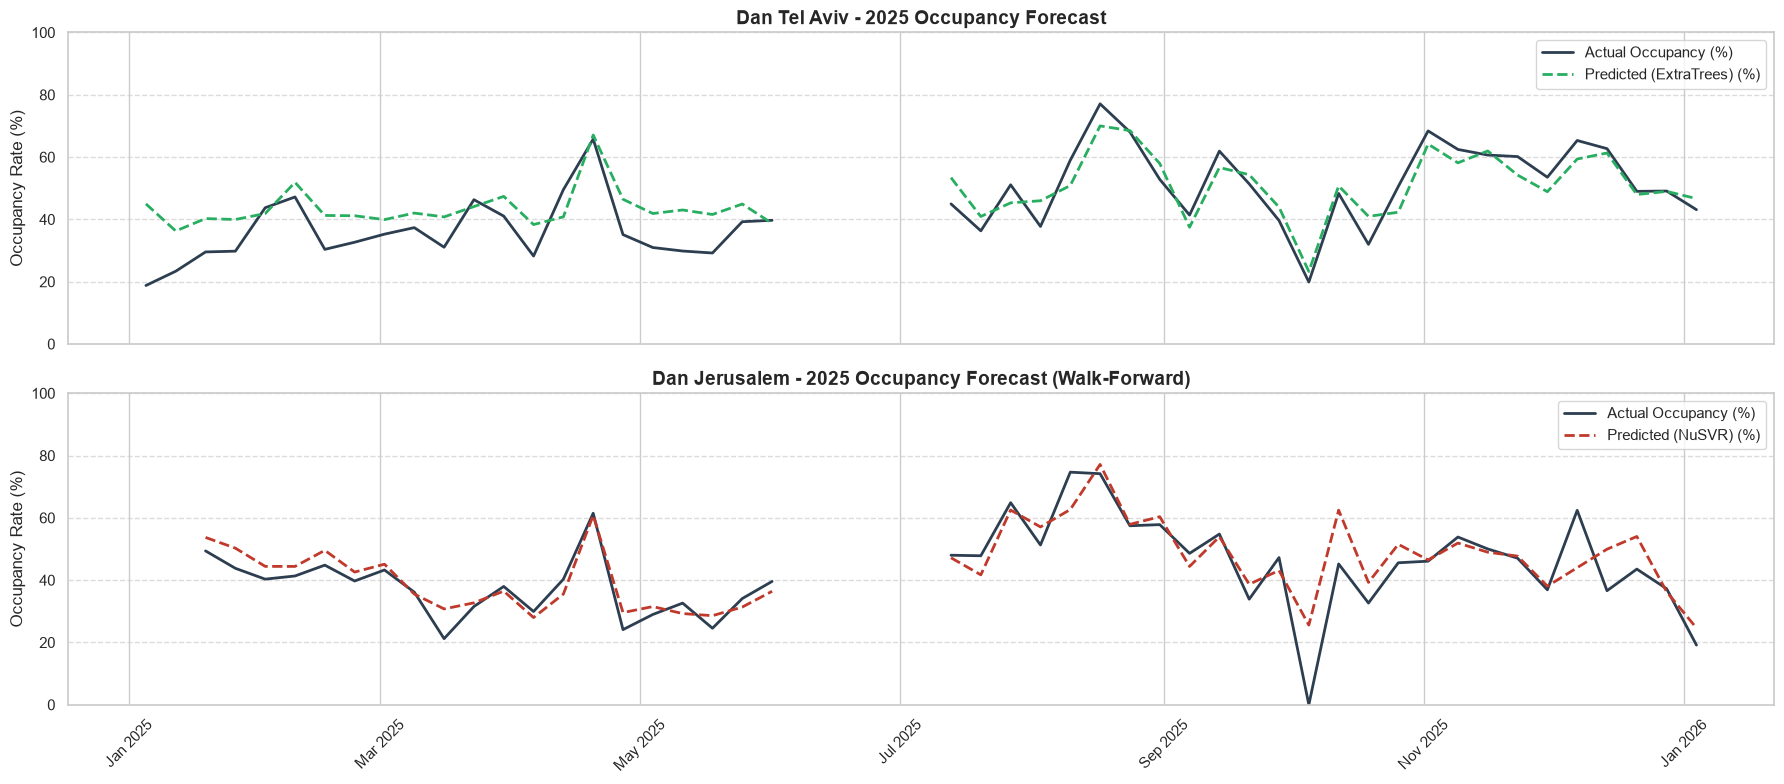

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


OUTPUTS_PATH = PROJECT_ROOT / 'outputs' 

# Load results
df_dt = pd.read_csv(os.path.join(OUTPUTS_PATH,'results_dt.csv'), parse_dates=['Date'])
df_dj = pd.read_csv(os.path.join(OUTPUTS_PATH,'results_dj.csv'), parse_dates=['Date'])

# Smooth by week for readability
dt_weekly = df_dt.resample('W', on='Date').mean()
dj_weekly = df_dj.resample('W', on='Date').mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# Dan Tel Aviv Plot
axes[0].plot(dt_weekly.index, dt_weekly['Actual'] * 100, label='Actual Occupancy (%)', color='#2c3e50', linewidth=2)
axes[0].plot(dt_weekly.index, dt_weekly['Predicted'] * 100, label='Predicted (ExtraTrees) (%)', color='#27ae60', linewidth=2, linestyle='--')
axes[0].set_title('Dan Tel Aviv - 2025 Occupancy Forecast', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Occupancy Rate (%)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, 100)

# Dan Jerusalem Plot
axes[1].plot(dj_weekly.index, dj_weekly['Actual'] * 100, label='Actual Occupancy (%)', color='#2c3e50', linewidth=2)
axes[1].plot(dj_weekly.index, dj_weekly['Predicted'] * 100, label='Predicted (NuSVR) (%)', color='#c0392b', linewidth=2, linestyle='--')
axes[1].set_title('Dan Jerusalem - 2025 Occupancy Forecast (Walk-Forward)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Occupancy Rate (%)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, 100)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'occupancy_forecast_2025.png'), dpi=300)
plt.show()